In [1]:
# 1. IMPORTAR LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# 2. CARGAR EL DATASET DEL TITANIC
# Usaremos una URL pública con el dataset clásico del Titanic
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print("Primeras filas del dataset original:")
display(df.head())

Primeras filas del dataset original:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# 3. PREPROCESAMIENTO DE DATOS (LIMPIEZA)
# Eliminamos columnas que no aportan a la predicción o son difíciles de procesar ahora mismo
df_clean = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# Rellenamos los valores nulos (vacíos)
# Para la edad, pondremos la mediana. Para el puerto de embarque ('Embarked'), pondremos el más común.
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Convertimos las variables de texto a números (Encoding)
df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})
df_clean['Embarked'] = df_clean['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [4]:
# 4. DEFINIR LAS CARACTERÍSTICAS (X) Y EL OBJETIVO (y)
X = df_clean.drop('Survived', axis=1) # Todo menos la columna a predecir
y = df_clean['Survived']              # Lo que queremos predecir (0 = No sobrevivió, 1 = Sobrevivió)

In [5]:
# 5. DIVIDIR LOS DATOS (ENTRENAMIENTO Y PRUEBA)
# Usaremos 80% de los datos para enseñar al modelo y 20% para examinarlo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# 6. CREAR Y ENTRENAR EL MODELO DE ÁRBOL DE DECISIÓN
# max_depth=3 limita el crecimiento del árbol para que no memorice los datos (evitar overfitting) y sea fácil de dibujar
modelo_arbol = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo_arbol.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [7]:
# 7. EVALUAR EL MODELO
y_pred = modelo_arbol.predict(X_test)

print("\n--- RESULTADOS DE LA PREDICCIÓN ---")
print(f"Precisión (Accuracy): {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['No Sobrevivió', 'Sobrevivió']))


--- RESULTADOS DE LA PREDICCIÓN ---
Precisión (Accuracy): 79.89%

Reporte de Clasificación:
               precision    recall  f1-score   support

No Sobrevivió       0.80      0.88      0.84       105
   Sobrevivió       0.80      0.69      0.74        74

     accuracy                           0.80       179
    macro avg       0.80      0.78      0.79       179
 weighted avg       0.80      0.80      0.80       179



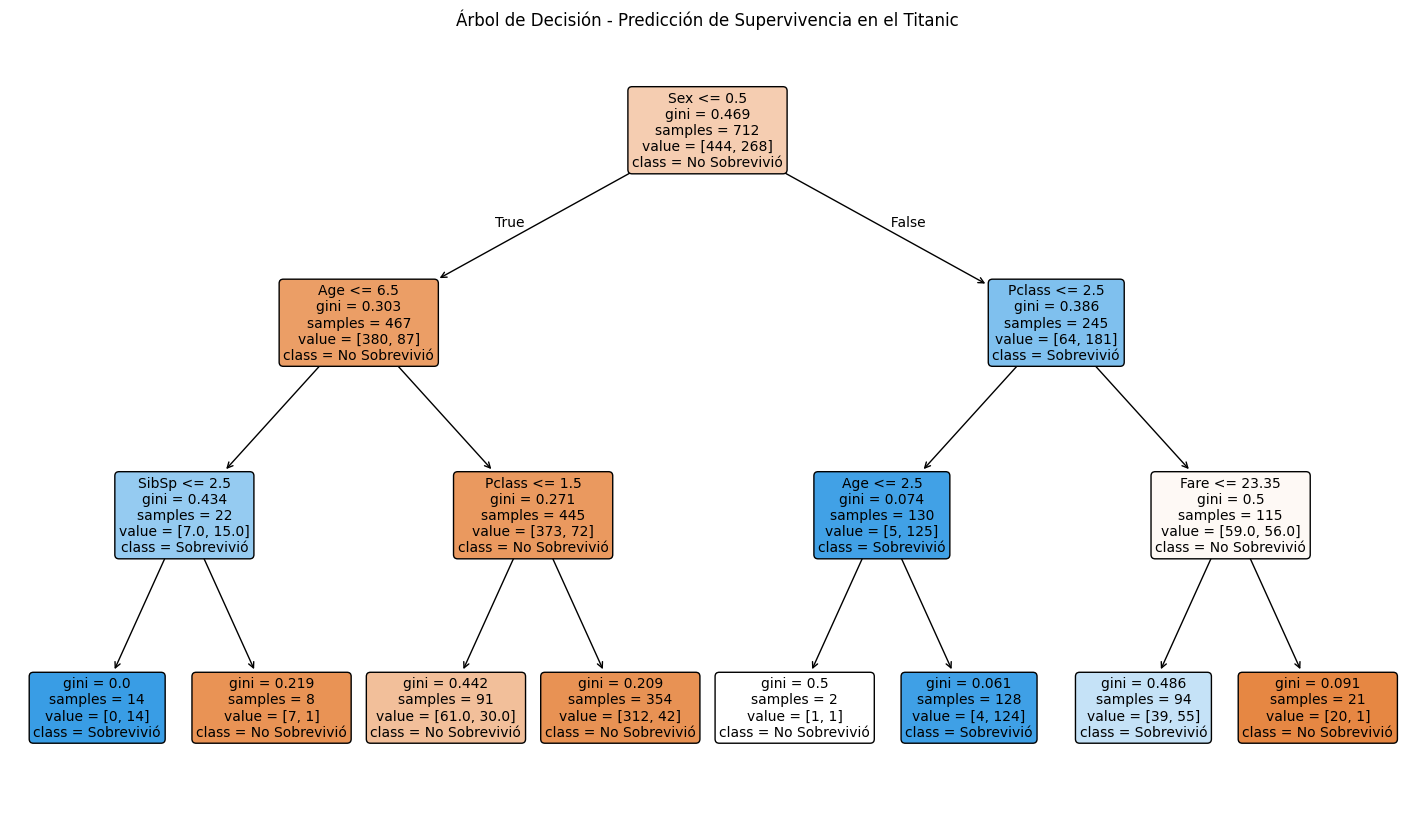

In [8]:
# 8. VISUALIZAR EL ÁRBOL
plt.figure(figsize=(18, 10))
plot_tree(modelo_arbol,
          feature_names=X.columns,
          class_names=['No Sobrevivió', 'Sobrevivió'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Árbol de Decisión - Predicción de Supervivencia en el Titanic")
plt.show()

--- MÉTRICAS DETALLADAS ---
Exactitud (Accuracy):  0.7989 -> De todas las predicciones, ¿qué porcentaje acertó?
Precisión (Precision): 0.7969 -> De los que el modelo dijo 'Sobrevivió', ¿cuántos sobrevivieron realmente?
Sensibilidad (Recall): 0.6892 -> De todos los que REALMENTE sobrevivieron, ¿qué porcentaje logró detectar el modelo?
F1-Score:              0.7391 -> Promedio equilibrado entre Precisión y Sensibilidad.
ROC-AUC:               0.8463 -> Capacidad general del modelo para distinguir entre clases (1.0 es perfecto).



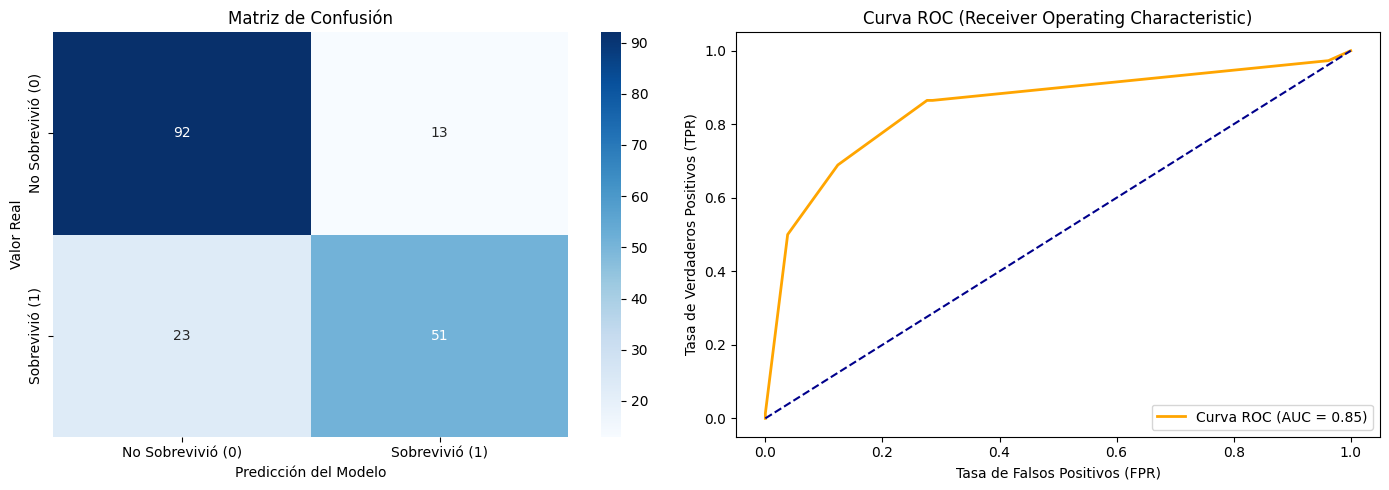

In [9]:
import seaborn as sns
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve)

# 1. Obtener predicciones (clases 0 o 1) y probabilidades (porcentajes)
y_pred = modelo_arbol.predict(X_test)
y_prob = modelo_arbol.predict_proba(X_test)[:, 1] # Probabilidad de ser de clase 1 (Sobrevivió)

# 2. Calcular las métricas individualmente
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("--- MÉTRICAS DETALLADAS ---")
print(f"Exactitud (Accuracy):  {accuracy:.4f} -> De todas las predicciones, ¿qué porcentaje acertó?")
print(f"Precisión (Precision): {precision:.4f} -> De los que el modelo dijo 'Sobrevivió', ¿cuántos sobrevivieron realmente?")
print(f"Sensibilidad (Recall): {recall:.4f} -> De todos los que REALMENTE sobrevivieron, ¿qué porcentaje logró detectar el modelo?")
print(f"F1-Score:              {f1:.4f} -> Promedio equilibrado entre Precisión y Sensibilidad.")
print(f"ROC-AUC:               {roc_auc:.4f} -> Capacidad general del modelo para distinguir entre clases (1.0 es perfecto).\n")

# 3. Visualizar Matriz de Confusión y Curva ROC
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- GRÁFICO 1: Matriz de Confusión ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['No Sobrevivió (0)', 'Sobrevivió (1)'],
            yticklabels=['No Sobrevivió (0)', 'Sobrevivió (1)'])
ax[0].set_title('Matriz de Confusión')
ax[0].set_xlabel('Predicción del Modelo')
ax[0].set_ylabel('Valor Real')

# --- GRÁFICO 2: Curva ROC ---
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
ax[1].plot(fpr, tpr, color='orange', linewidth=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='darkblue', linestyle='--') # Línea de modelo aleatorio
ax[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
ax[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax[1].set_title('Curva ROC (Receiver Operating Characteristic)')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()